In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("global-data-on-sustainable-energy.csv")

## Dataset Overview

This dataset contains global information related to sustainable energy, electricity access, renewable energy generation, carbon emissions, GDP, and other environmental indicators across different countries and years.

It can be used to analyse renewable energy trends and understand factors affecting sustainable development.

The dataset contains both numerical and categorical features and is suitable for regression analysis.

In [3]:
print("Dataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

Dataset Shape
(3649, 21)

Column Names
Index(['Entity', 'Year', 'Access to electricity (% of population)',
       'Access to clean fuels for cooking',
       'Renewable-electricity-generating-capacity-per-capita',
       'Financial flows to developing countries (US $)',
       'Renewable energy share in the total final energy consumption (%)',
       'Electricity from fossil fuels (TWh)', 'Electricity from nuclear (TWh)',
       'Electricity from renewables (TWh)',
       'Low-carbon electricity (% electricity)',
       'Primary energy consumption per capita (kWh/person)',
       'Energy intensity level of primary energy (MJ/$2017 PPP GDP)',
       'Value_co2_emissions_kt_by_country',
       'Renewables (% equivalent primary energy)', 'gdp_growth',
       'gdp_per_capita', 'Density\n(P/Km2)', 'Land Area(Km2)', 'Latitude',
       'Longitude'],
      dtype='object')

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 21 colum

## Handling Missing Values

The dataset contains missing values in both numerical and categorical columns.

- The **Entity** column has no missing values.
- The **Density (P/Km2)** column has one missing value and is treated as a categorical/text column.
- Numerical columns are filled using the **median** because the dataset contains several columns with large variations and possible outliers.
- Median is less affected by extreme values than the mean and provides a more robust estimate.

After preprocessing, the dataset will be free from missing values and ready for machine learning.

In [5]:
# Fill all categorical (object) columns using mode
object_columns = df.select_dtypes(include=["object"]).columns

for col in object_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill all numerical columns using median
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

print("Missing Values After Cleaning")
print(df.isnull().sum())

Missing Values After Cleaning
Entity                                                              0
Year                                                                0
Access to electricity (% of population)                             0
Access to clean fuels for cooking                                   0
Renewable-electricity-generating-capacity-per-capita                0
Financial flows to developing countries (US $)                      0
Renewable energy share in the total final energy consumption (%)    0
Electricity from fossil fuels (TWh)                                 0
Electricity from nuclear (TWh)                                      0
Electricity from renewables (TWh)                                   0
Low-carbon electricity (% electricity)                              0
Primary energy consumption per capita (kWh/person)                  0
Energy intensity level of primary energy (MJ/$2017 PPP GDP)         0
Value_co2_emissions_kt_by_country                           

## Dataset Understanding

### General Observations

- The dataset contains 3,649 records and 21 features.
- It includes information about electricity access, renewable energy, carbon emissions, GDP and sustainable development.
- Most features are numerical, making the dataset suitable for regression analysis.
- Some columns initially contained missing values, which were handled using median and mode.
- The dataset combines economic, environmental and energy-related indicators from different countries over multiple years.

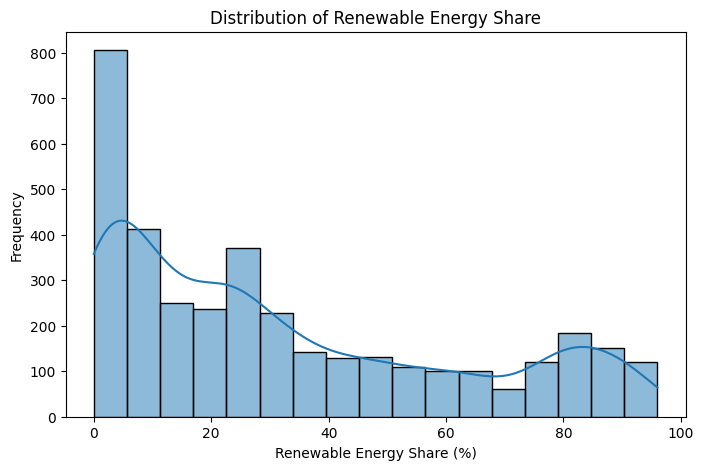

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(df["Renewable energy share in the total final energy consumption (%)"], kde=True)

plt.title("Distribution of Renewable Energy Share")
plt.xlabel("Renewable Energy Share (%)")
plt.ylabel("Frequency")

plt.show()

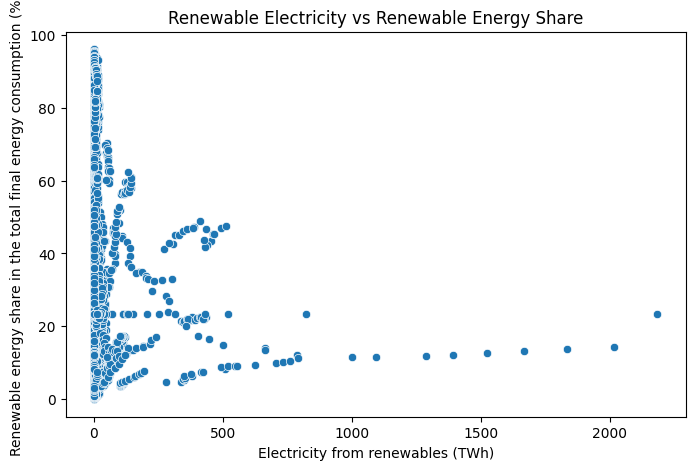

In [7]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Electricity from renewables (TWh)",
    y="Renewable energy share in the total final energy consumption (%)"
)

plt.title("Renewable Electricity vs Renewable Energy Share")

plt.show()

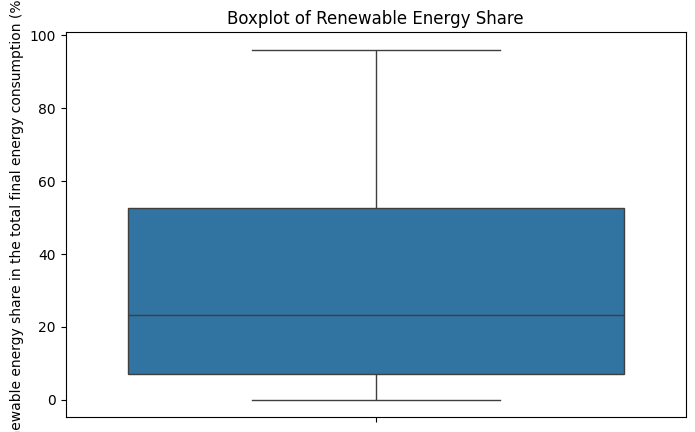

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    y="Renewable energy share in the total final energy consumption (%)"
)

plt.title("Boxplot of Renewable Energy Share")

plt.show()

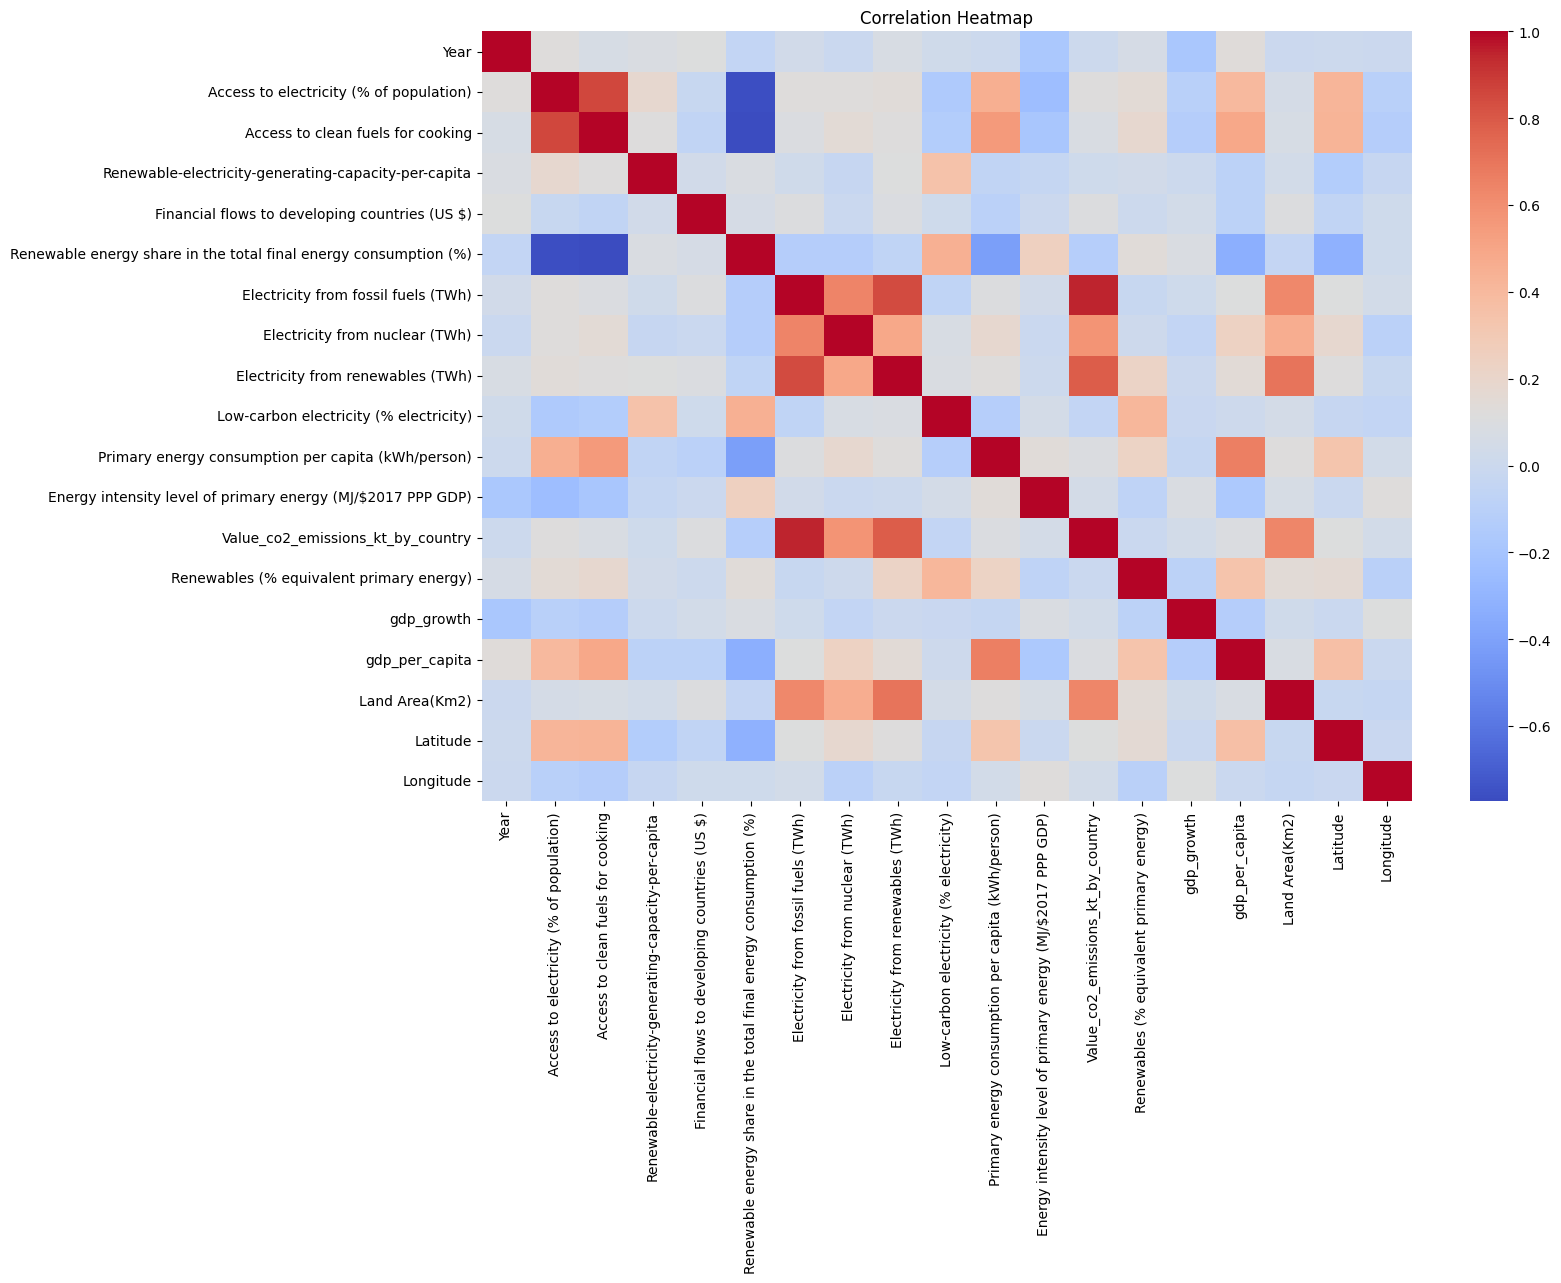

In [9]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Visualization Insights

- The histogram shows the distribution of renewable energy share.
- The scatter plot helps identify the relationship between renewable electricity generation and renewable energy share.
- The box plot helps detect outliers in renewable energy share.
- The heatmap displays correlations among numerical features, helping identify variables that are positively or negatively related.

In [15]:
for col in df.columns:
    print(repr(col))

'Year'
'Access to electricity (% of population)'
'Access to clean fuels for cooking'
'Renewable-electricity-generating-capacity-per-capita'
'Financial flows to developing countries (US $)'
'Renewable energy share in the total final energy consumption (%)'
'Electricity from fossil fuels (TWh)'
'Electricity from nuclear (TWh)'
'Electricity from renewables (TWh)'
'Low-carbon electricity (% electricity)'
'Primary energy consumption per capita (kWh/person)'
'Energy intensity level of primary energy (MJ/$2017 PPP GDP)'
'Value_co2_emissions_kt_by_country'
'Renewables (% equivalent primary energy)'
'gdp_growth'
'gdp_per_capita'
'Density\\n(P/Km2)'
'Land Area(Km2)'
'Latitude'
'Longitude'
'Entity_Albania'
'Entity_Algeria'
'Entity_Angola'
'Entity_Antigua and Barbuda'
'Entity_Argentina'
'Entity_Armenia'
'Entity_Aruba'
'Entity_Australia'
'Entity_Austria'
'Entity_Azerbaijan'
'Entity_Bahamas'
'Entity_Bahrain'
'Entity_Bangladesh'
'Entity_Barbados'
'Entity_Belarus'
'Entity_Belgium'
'Entity_Belize'
'Ent

In [ ]:
df["Density\\n(P/Km2)"] = (
    df["Density\\n(P/Km2)"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df["Density\\n(P/Km2)"] = pd.to_numeric(
    df["Density\\n(P/Km2)"],
    errors="coerce"
)

df["Density\\n(P/Km2)"] = df["Density\\n(P/Km2)"].fillna(
    df["Density\\n(P/Km2)"].median()
)
print(df.select_dtypes(include="object").columns)


Index([], dtype='object')


In [18]:
print(df.isnull().sum().sum())
print(df.shape)

0
(3649, 195)


In [ ]:
df = pd.get_dummies(df, columns=["Entity"], drop_first=True)

print(df.head())

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_columns = df.select_dtypes(include=["int64","float64"]).columns

df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

print(df.head())

   Year  Access to electricity (% of population)  \
0  2000                                 1.613591   
1  2001                                 4.074574   
2  2002                                 9.409158   
3  2003                                14.738506   
4  2004                                20.064968   

   Access to clean fuels for cooking  \
0                                6.2   
1                                7.2   
2                                8.2   
3                                9.5   
4                               10.9   

   Renewable-electricity-generating-capacity-per-capita  \
0                                               9.22      
1                                               8.86      
2                                               8.47      
3                                               8.09      
4                                               7.75      

   Financial flows to developing countries (US $)  \
0                                     

# Feature Scaling and Encoding

Before training the machine learning model, the dataset must be preprocessed.

- Feature Scaling is applied to numerical columns using **StandardScaler** so that all numerical features are on a similar scale.
- The **Entity** column is categorical, so it is converted into numerical format using **pd.get_dummies()**.
- These preprocessing steps improve the performance and compatibility of machine learning algorithms.

In [19]:
X = df.drop(
    "Renewable energy share in the total final energy consumption (%)",
    axis=1
)

y = df["Renewable energy share in the total final energy consumption (%)"]

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train-Test Split

The dataset is divided into training and testing sets.

- Training data is used to train the Linear Regression model.
- Testing data is used to evaluate the model on unseen data.
- An 80:20 split is used, where 80% of the data is used for training and 20% for testing.

# Linear Regression Model

Linear Regression is a supervised machine learning algorithm used to predict continuous numerical values.

In this project, the model is used to predict the **Renewable energy share in the total final energy consumption (%)** based on various energy, economic and environmental indicators.

In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# Prediction

After training the Linear Regression model, predictions are made on the testing dataset.

These predicted values are compared with the actual values to evaluate the model's performance.

In [23]:
y_pred = model.predict(X_test)

print("Predicted Values:")
print(y_pred[:10])

Predicted Values:
[ 1.3581327  -1.0225281   1.49632974  0.98085332 -0.59830978 -1.14304474
 -0.70890887 -0.99562272  1.08132851  1.55033727]


# Model Evaluation

The Linear Regression model is evaluated using different regression metrics.

The following metrics are used:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics help determine the accuracy and performance of the regression model.

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 0.12436027345760634
Mean Squared Error (MSE): 0.04401216620300843
Root Mean Squared Error (RMSE): 0.20979076767819987
R2 Score: 0.9559148142710544


# Actual vs Predicted Values

The table below compares the actual target values with the values predicted by the Linear Regression model.

In [25]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
1406,1.141897,1.358133
3598,-1.065197,-1.022528
3646,1.649089,1.496330
3230,1.094915,0.980853
3114,-0.595041,-0.598310
1593,-1.082687,-1.143045
1580,-1.089888,-0.708909
3456,-0.880015,-0.995623
1514,1.028044,1.081329
2016,-0.303208,1.550337


# Prediction Visualization

The scatter plot below compares the actual values with the predicted values.

If the predicted points are close to the actual values, the model performs well.

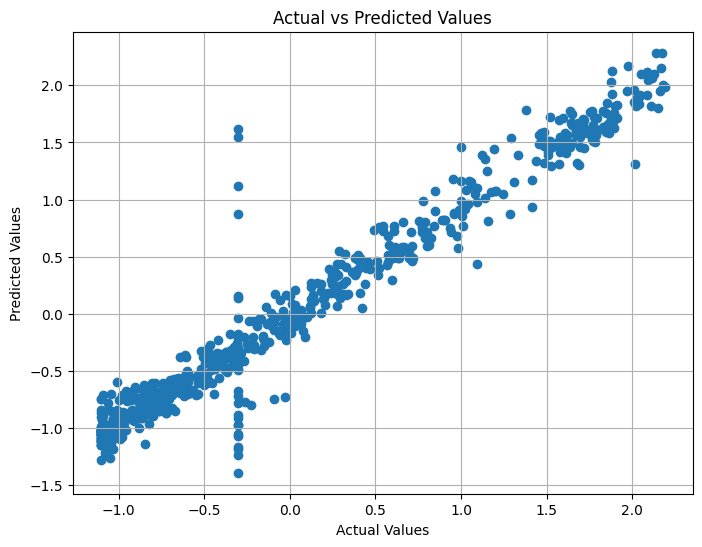

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

plt.grid(True)

plt.show()

# Final Insights

- The dataset was successfully analysed and preprocessed.
- Missing values were handled using suitable techniques.
- Categorical features were converted into numerical format using **pd.get_dummies()**.
- Numerical features were standardized using **StandardScaler**.
- The dataset was divided into training and testing sets using an 80:20 ratio.
- A Linear Regression model was trained to predict the renewable energy share.

## Model Performance

- **MAE** represents the average prediction error. Lower values indicate better performance.
- **MSE** gives higher importance to larger errors. Smaller values indicate a better model.
- **RMSE** represents the average prediction error in the same unit as the target variable.
- **R² Score** indicates how well the model explains the variation in the target values. A value closer to **1** indicates a better fit.

## Conclusion

The Linear Regression model successfully predicts the renewable energy share using the selected energy, economic and environmental indicators. The evaluation metrics help measure the accuracy and reliability of the model.